# [Azure OpenAI Responses API's](https://learn.microsoft.com/en-us/azure/ai-services/openai/how-to/responses?tabs=python-secure#generate-a-text-response) (with Entra ID authentication)

In [1]:
import os
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv # requires python-dotenv

load_dotenv("./../../../../config/credentials_my.env")

os.environ["AZURE_OPENAI_ENDPOINT"] = os.environ['AZURE_OPENAI_ENDPOINT']

api_version = "2025-03-01-preview"

credential = DefaultAzureCredential()

token_provider = get_bearer_token_provider(
    DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default")

client = AzureOpenAI(
  azure_ad_token_provider=token_provider,
  api_version=api_version)

question = "Tell me what Microsoft Azure is in less than 20 words"

# Chat Completions API's

In [2]:
response = client.chat.completions.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    messages=[
        {"role": "system", "content": "You are an assistant."},
        {"role": "user", "content": question}
    ])

print(f"Response: {response.choices[0].message.content}")

response

Response: Microsoft Azure is a cloud computing platform offering services like virtual machines, databases, storage, AI, and networking.


ChatCompletion(id='chatcmpl-BJfNkdNukIqzrU6kHgRdWNMpeRLaM', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Microsoft Azure is a cloud computing platform offering services like virtual machines, databases, storage, AI, and networking.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None), content_filter_results={'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}})], created=1744027004, model='gpt-4o-2024-08-06', object='chat.completion', service_tier=None, system_fingerprint='fp_ee1d74bde0', usage=CompletionUsage(completion_tokens=23, prompt_tokens=28, total_tokens=51, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=

# [OpenAI Responses API's on Azure](https://learn.microsoft.com/en-us/azure/ai-services/openai/how-to/responses?tabs=python-secure#generate-a-text-response)

In [3]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=question)

print(f"Response: {response.output_text}")

response

Response: Microsoft Azure is a cloud platform offering services like computing, storage, databases, and AI for businesses.


Response(id='resp_67f3bd7cd410819096ea01251c2f8769', created_at=1744027004.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4o', object='response', output=[ResponseOutputMessage(id='msg_67f3bd7d6f988190b7e0061a44bf2633', content=[ResponseOutputText(annotations=[], text='Microsoft Azure is a cloud platform offering services like computing, storage, databases, and AI for businesses.', type='output_text')], role='assistant', status='completed', type='message')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=1.0, max_output_tokens=None, previous_response_id=None, reasoning=Reasoning(effort=None, generate_summary=None), status='completed', text=ResponseTextConfig(format=ResponseFormatText(type='text')), truncation='disabled', usage=ResponseUsage(input_tokens=36, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=22, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=58), user=Non

# Responses API's with multimodal answers

In [4]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=[
        {"role": "user", "content": "what teams are playing football here?"},
        {
            "role": "user", 
            "content": [
                {                    
                    "type": "input_image",
                    "image_url": "https://cdn.vox-cdn.com/thumbor/Af-npOeOqJ6EbLp0sepLAlHDwFU=/0x0:4275x2623/1200x800/filters:focal(1796x970:2480x1654)/cdn.vox-cdn.com/uploads/chorus_image/image/71292710/1242757033.0.jpg"
                },
            ],
        },
    ],
)

print(f"Response: {response.output_text}")

Response: The teams playing are Juventus and Roma. Juventus is wearing the white and black striped kit, while Roma is in the red kit.


# Responses API's support streaming ;-)

In [5]:
stream = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=f"{question} using not less than 200 words",
    stream = True
)

for event in stream:
    if hasattr(event, "type") and "text.delta" in event.type:
        print(event.delta, end="", flush=True)

Microsoft Azure is a cloud computing platform offering a wide range of services like compute, analytics, storage, and networking.

Azure provides scalable solutions for businesses, enabling them to build, manage, and deploy applications globally. It supports various programming languages, frameworks, and operating systems, facilitating diverse development needs. Azure's infrastructure-as-a-service (IaaS) and platform-as-a-service (PaaS) models allow organizations to deploy virtual machines, databases, and app services effortlessly. With integrated tools for building AI-driven applications, Azure empowers innovation with machine learning, bots, and cognitive services.

Security and compliance are emphasized through features like Azure Security Center, identity management, and encryption. Azure's hybrid capabilities allow seamless integration with on-premises environments, giving flexibility and control to enterprises. Services like Azure DevOps enable continuous integration and developm

# Inputs can now be a single string or a list of messages

In [12]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=question)

print(f"Response: {response.output_text}")

response

Response: Microsoft Azure is a cloud platform offering computing, analytics, storage, and networking services for scalable applications.


Response(id='resp_67f3bf6034ec81908246a605e0b36d3e', created_at=1744027488.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4o', object='response', output=[ResponseOutputMessage(id='msg_67f3bf606ff481908cf7419b4ca789f6', content=[ResponseOutputText(annotations=[], text='Microsoft Azure is a cloud platform offering computing, analytics, storage, and networking services for scalable applications.', type='output_text')], role='assistant', status='completed', type='message')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=1.0, max_output_tokens=None, previous_response_id=None, reasoning=Reasoning(effort=None, generate_summary=None), status='completed', text=ResponseTextConfig(format=ResponseFormatText(type='text')), truncation='disabled', usage=ResponseUsage(input_tokens=36, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=22, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens

# The list of roles can now be:
- system
- user
- assistant
- **developer**
<br/>
### Priority and hierarchy is defined as explained in the article [The chain of command](https://model-spec.openai.com/2025-02-12.html#chain_of_command)

In [10]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=[
        {"role": "developer", "content": "talk like a poet"}, # you may use "instructions" as a role too
        {"role": "user", "content": question}])

print(f"Response: {response.output_text}")

Response: Azure, a realm of cloud dreams, where data dances, scales soar, and solutions weave in ethereal streams.


In [11]:
# As an alternative to the developer role...

response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    instructions = "talk like a poet",
    input=[
        {"role": "user", "content": question}])

print(f"Response: {response.output_text}")

Response: A celestial realm of cloud services, where digital dreams ascend, and innovation dances on virtual winds.


# From list of messages...

In [22]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=[
        {"role": "system", "content": "You are an intelligent Assistant"},
        {"role": "user", "content": "how much is two plus two"},
        {"role": "assistant", "content": "Two plus two equals four"},
        {"role": "user", "content": "explain me why, in less than ten words"}])

print(f"Response: {response.output_text}")

Response: Adding quantities: 2 + 2 combines into 4.


# ... to Conversation states

In [23]:
first_response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input = "how much is two plus two"
)

print(f"Response: {first_response.output_text}")

second_response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    previous_response_id = first_response.id,
    input = "explain me why, in less than ten words"
)

print(f"Response: {second_response.output_text}")

Response: Two plus two equals four.
Response: Adding two and two results in four objects total.


# Two ways to produce a Structured Output

## - by specifying a JSON schema (traditional way of Chat Completions API's)...

In [53]:
import json

response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input=[
        {"role": "system", "content": "Extract the travel information"},
        {"role": "user", "content": "I'm going to spend a week since Easter day 2025 in Seattle together with my wife Alessandra and my daughters Michela and Federica"},
    ],
    text = {
        "format": {
            "type": "json_schema",
            "name": "travel",
            "schema": {
                "type": "object",
                "properties": {
                    "destination": {"type": "string"},
                    "date": {"type": "string"},
                    "people": {"type": "array", "items": {"type": "string"}}
                },
                "required": ["destination", "date", "people"],
                "additionalProperties": False
            },
            "strict": True
        }
    }
)

json.loads(response.output_text)

{'destination': 'Seattle',
 'date': '2025-04-20 to 2025-04-27',
 'people': ['Alessandra', 'Michela', 'Federica']}

## ...or by using a [Pydantic model](https://news.ycombinator.com/item?id=43336251)
Pydantic is a Python library used for data validation and parsing with type-based models. It ensures data accuracy and consistency, making it easier to work with structured data. It's especially useful for applications like APIs and managing complex inputs.

In [56]:
from pydantic import BaseModel
from typing import List

class Travel (BaseModel):
    destination: str
    date: str
    duration: int
    people: List[str]

response = client.responses.parse(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    input="I'm going to spend a week since Easter day 2025 in Seattle together with my wife Alessandra and my daughters Michela and Federica",
    instructions = "Extract the travel information",
    text_format = Travel,
)

response_model = response.output[0].content[0].parsed

print(f"Response: {response_model.model_dump_json(indent=3)}")

Response: {
   "destination": "Seattle",
   "date": "2025-04-20",
   "duration": 7,
   "people": [
      "Alessandra",
      "Michela",
      "Federica"
   ]
}


# WEB Search Tool (not working yet Azure OpenAI yet)

In [61]:
response = client.responses.create(
    model=os.environ['AZURE_OPENAI_CHAT_DEPLOYMENT_NAME'],
    tools = [
        {
            "type": "web_search_preview",
            "user_location": {
                "type": "approximate",
                "country": "IT",
                "city": "Milan"
            },
        }
    ],
    input="What are the restaurants around P.zza Piola?"
)

print(f"Response: {response.output_text}, {response.output[1].content[0].annotations}, {response.output[1].content[0].annotations[0].url}")

Response: {"date":"2025-04-20","duration":7,"destination":"Seattle","people":["Alessandra","Michela","Federica"]}


# File Search and Semantic Search
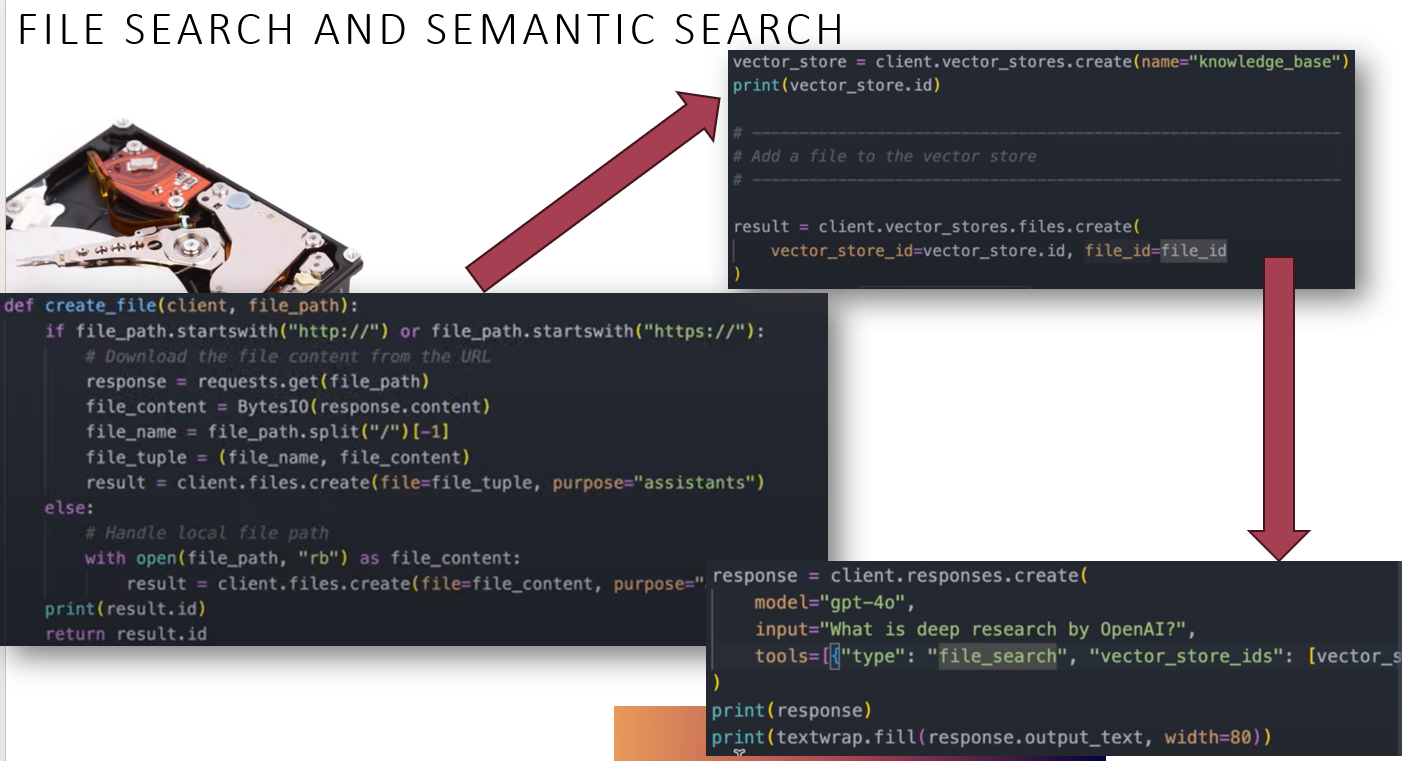

# Reasoning

In [72]:
prompt = """
I have $20,000 in my savings account, where I receive a 4% profit per year and payments twice a year. 
Can you please tell me how long it will take for me to become a millionaire? 
Also, can you please explain the math step by step as if you were explaining it to an uneducated person?
"""

response = client.responses.create(
    model="o3-mini",
    reasoning = {"effort": "medium"}, # one of low, medium, or high for this parameter,
    input=[{"role": "user", "content": prompt}],
)

print(f"Response: {response}")

Response: 
